In [61]:
# 기본 경로 설정
# ===============================================================
import os
import requests

PROJECT_NUM = "15"

ROOT_DIR = os.getcwd()

try:
    from google.colab import drive, userdata
    IS_COLAB_MODE = True
    print("코랩 모드")

except ModuleNotFoundError as e:
    IS_COLAB_MODE = False
    ROOT_DIR = os.path.dirname(ROOT_DIR)
    print(f"{e}: 로컬 모드")


DATA_DIR = os.path.join(ROOT_DIR, "data")
RAW_DIR = os.path.join(DATA_DIR, "raw")
os.makedirs(DATA_DIR, exist_ok=True)


# 환경변수 로드 설정
def get_secret(key_name: str):
    if IS_COLAB_MODE:
        return userdata.get(key_name)
    else:
        from dotenv import load_dotenv
        load_dotenv(dotenv_path=os.path.join(ROOT_DIR, ".env"))
        return os.getenv(key_name)


if IS_COLAB_MODE:
    import subprocess

    drive.mount('/content/drive')

    # 압축 파일 확보
    if "raw.tar.gz" not in os.listdir():

        headers = {
            "Authorization": f"token {get_secret('GITHUB_PAT')}",
            "Accept": "application/vnd.github.v3+json"
        }

        release_url = f"https://api.github.com/repos/wonbywondev/ML-DL-data/releases/tags/data-rag"

        response = requests.get(release_url, headers=headers)
        asset_id = response.json().get('assets', [])[0]["id"]

        download_url = f"https://api.github.com/repos/wonbywondev/ML-DL-data/releases/assets/{asset_id}"
        download_headers = headers.copy()
        download_headers["Accept"] = "application/octet-stream"

        with requests.get(download_url, headers=download_headers, stream=True) as r:
            r.raise_for_status()
            with open("raw.tar.gz", 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)

    print("· 압축 파일 있음")


    # 압축 해제 및 경로 처리
    if not os.path.exists(RAW_DIR):
        subprocess.run(["tar", "-xzvf", "raw.tar.gz", "-C", DATA_DIR], check=False)

    print("· 압축 해제 완료")
    print("· 환경 세팅 완료")


    DRIVE_DIR = os.path.join(ROOT_DIR, "drive", "MyDrive")
    SAVE_DIR = os.path.join(DRIVE_DIR, "runs", PROJECT_NUM)

    os.makedirs(SAVE_DIR, exist_ok=True)

No module named 'google': 로컬 모드


In [62]:
# 기타 환경 설정
import torch
import matplotlib.pyplot as plt
import gc


# 시각화 관련 설정
if not IS_COLAB_MODE:
    import matplotlib.font_manager as fm
    try:
        plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
    except:
        try:
            plt.rcParams['font.family'] = 'NanumGothic'
        except:
            plt.rcParams['font.family'] = 'AppleGothic'

    plt.rcParams['axes.unicode_minus'] = False
    fm._load_fontmanager(try_read_cache=False)


# 디바이스 설정
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps") # 맥 GPU
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda") # 윈도우 GPU
else:
    DEVICE = torch.device("cpu") # CPU


# 캐시 지우기 함수 생성
def clean_cache():
    gc.collect()
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()


# MallocStackLogging 에러 출력 방지
os.environ.pop("MallocStackLogging", None)
os.environ.pop("MallocStackLoggingNoCompact", None)
os.environ.pop("DYLD_INSERT_LIBRARIES", None)

## 협업 시나리오

1. [연구자 1]은 \`train.csv\` 데이터를 기반으로 Jupyter Notebook(\`.ipynb\`)에서 
   데이터 전처리, 탐색적 데이터 분석(EDA), 

In [63]:
import pandas as pd

train_csv_path = os.path.join(RAW_DIR, "mission15_train.csv")
test_csv_path = os.path.join(RAW_DIR, "mission15_test.csv")

train_df = pd.DataFrame(pd.read_csv(train_csv_path))
test_df = pd.DataFrame(pd.read_csv(test_csv_path))

In [64]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     7000 non-null   int64  
 1   Previous Scores                   7000 non-null   int64  
 2   Extracurricular Activities        7000 non-null   str    
 3   Sleep Hours                       7000 non-null   int64  
 4   Sample Question Papers Practiced  7000 non-null   int64  
 5   Performance Index                 7000 non-null   float64
dtypes: float64(1), int64(4), str(1)
memory usage: 328.3 KB


In [65]:
train_df.head(5)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,6,73,No,7,2,58.0
1,1,89,Yes,7,2,64.0
2,3,97,Yes,8,0,75.0
3,8,70,No,5,5,59.0
4,7,94,Yes,7,4,86.0


In [66]:
# 전처리

# 중복치 제거
train_df = train_df.drop_duplicates()

# 쓸모 없는 float -> int로 변환
train_df["Performance Index"] = train_df["Performance Index"].astype(int)

# str(y/n) -> int로 변환
def yn_to_int(df: pd.DataFrame):    
    df["Extracurricular Activities"] = (
        df["Extracurricular Activities"].replace({"No": "0", "Yes": "1"})
    ).astype(int)

    return df

train_df = yn_to_int(train_df)
test_df = yn_to_int(test_df)

In [67]:
train_df.describe()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,6936.000000,6936.000000,6936.000000,6936.000000,6936.000000,6936.000000
mean,4.945646,69.439014,0.496828,6.533160,4.610582,55.091407
std,2.592388,17.265709,0.500026,1.698652,2.862662,19.142497
min,1.000000,40.000000,0.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,0.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,0.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,1.000000,8.000000,7.000000,70.000000
max,9.000000,99.000000,1.000000,9.000000,9.000000,100.000000


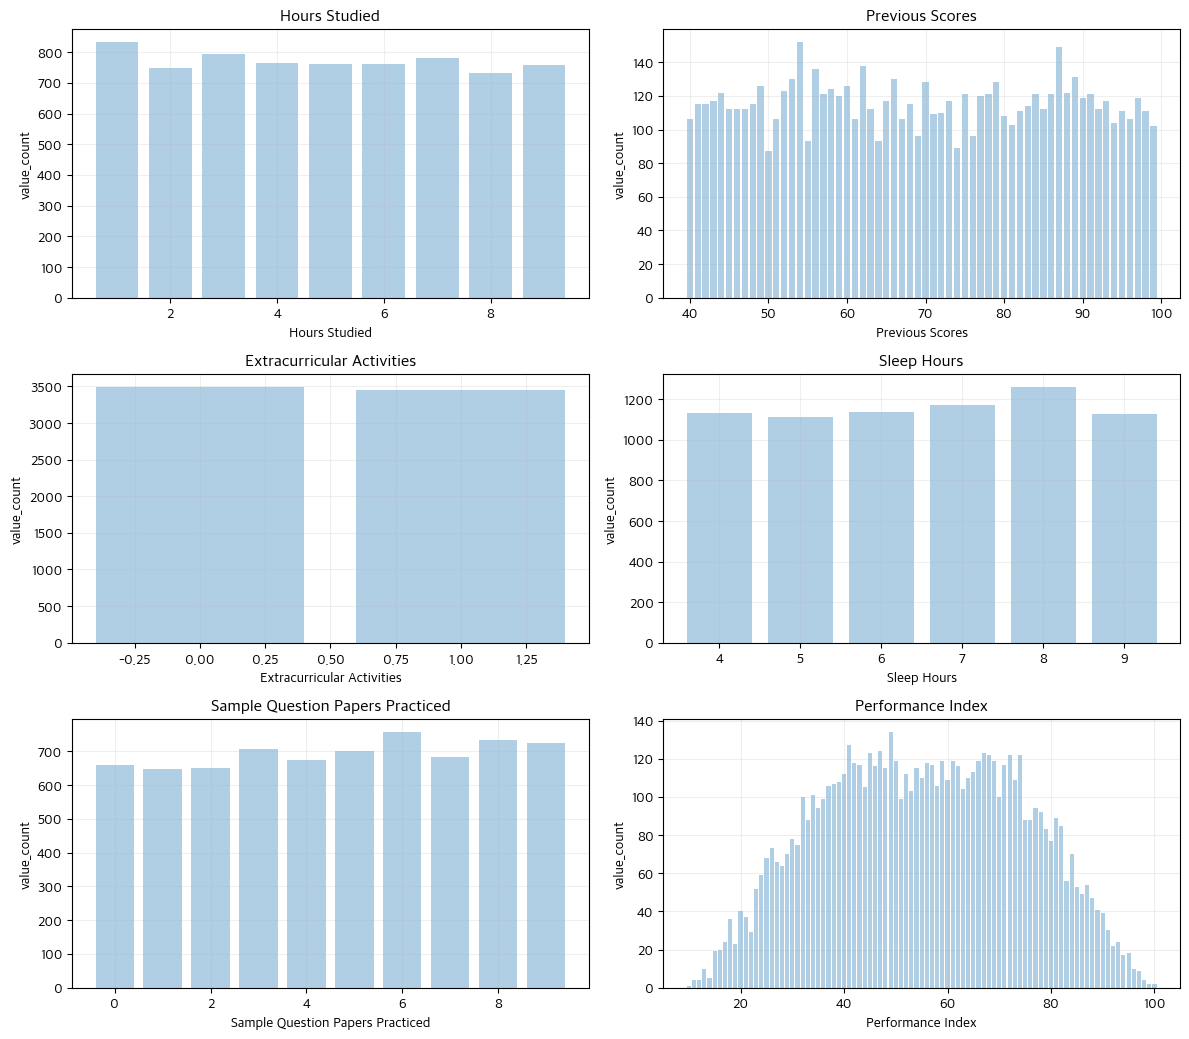

In [68]:
import math
import numpy as np
import matplotlib.pyplot as plt

cols = train_df.columns

n = len(cols)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 3.5*nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, cols):
    s = train_df[col]
    vc = s.value_counts().sort_index()

    x = vc.index.to_numpy(dtype=float)
    y = vc.values

    ax.bar(x, y, alpha=0.35, label="value_counts")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("value_count")
    ax.grid(alpha=0.2)

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()

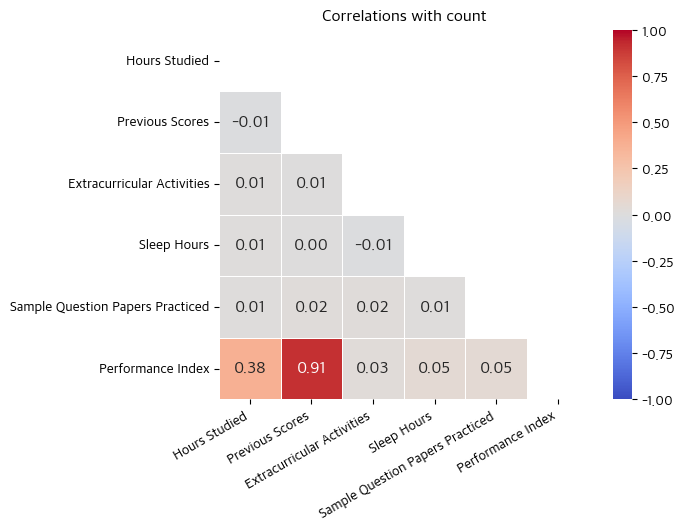

In [69]:
import seaborn as sns

corr = train_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure()

sns.heatmap(
    corr,
    annot=True,
    square=True,
    fmt=".2f",
    mask=mask,
    linewidths=.5,
    vmin=-1,
    vmax=1,
    annot_kws={"size": 12},
    cmap="coolwarm",
    cbar_kws={"shrink": 1},
)

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.title(f"Correlations with count")

plt.show()

전체적으로 자연스러운 분포를 보이므로 극단치와 이상치는 없다고 판단한다.

그리고 \`scikit-learn\`을 사용한 회귀 모델링을 수행한다. 
2. 모델 성능은 RMSE로 평가하며, 최종 모델은 \`model.pkl\` 파일로 저장한다. 
3. 이후, 전처리 - 모델링 - 모델 저장 과정을 하나의 \`.py\` 스크립트로 정리한다. 
4. [연구자 1]은 이 작업을 자동화하는 도커 이미지를 구축하여 Docker Hub에 업로드한다.

In [70]:
import copy

TRAIN_DF = copy.deepcopy(train_df)
TEST_DF = copy.deepcopy(test_df)

In [71]:
from sklearn.model_selection import train_test_split

X_whole = TRAIN_DF.drop("Performance Index", axis=1)
y_whole = TRAIN_DF["Performance Index"]

X_train, X_val, y_train, y_val = train_test_split(X_whole, y_whole, test_size=0.2, random_state=42)

X_test = TEST_DF.copy()

In [72]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error as rmse

model = LinearRegression()

model.fit(X_train, y_train)

y_val_pred = model.predict(X_val)

val_loss = rmse(y_val, y_val_pred)

print(f"· RMSE: {val_loss:.4f}")

· RMSE: 2.0375


In [73]:
import pickle

pkl_path = os.path.join(DATA_DIR, "model", "model.pkl")
os.makedirs(os.path.dirname(pkl_path), exist_ok=True)

with open(pkl_path, "wb") as f:
    pickle.dump(model, f)


---

```
1. [연구자 2]는 [연구자 1]이 생성한 도커 이미지와 별도의 Jupyter Notebook 도커 이미지를 \`docker-compose\`로 구성한다.
2. [연구자 2]는 [연구자 1]의 도커 컨테이너에서 생성된 \`model.pkl\` 파일과 컨테이너 내부의 \`test.csv\` 파일을 활용하여 
   Jupyter Notebook 컨테이너에서 추론을 수행하고, 결과를 \`result.csv\` 파일로 저장한다. 
3. 전체 추론 과정이 담긴 inference.ipynb 파일을 별도로 저장한다.

(참고: [연구자 2]는 사전에 데이터나 모델 파일을 보유하지 않은 상태이며, 
      [연구자 1]의 Docker Hub 이미지를 통해 필요한 파일을 가져와야 한다.)


## 제출 안내

미션 15 폴더 하위에 {팀명}\_{이름}으로 폴더를 생성하고, 그 안에 **코드 폴더** 와 **보고서 pdf(2페이지 이내)** 를 제출해 주세요.

1. **코드 폴더** (`mission-result`): 실제 작성한 코드를 제출해주세요.
2. **보고서 PDF** (2페이지 이내): 보고서 내용에는 다음의 항목들이 포함되어있어야 합니다.
	- Docker Hub URL
	- 연구자 1의 데이터 전처리 및 모델링 결과 요약
	- 코드 아키텍처 도식 및 설명


## 참고 사항

아래와 같은 내용을 신경써서 작업해주세요.

1. 두 연구자의 Python 버전과 패키지 버전을 동일하게 유지하는 방안
2. 연구자 1의 컨테이너에 있는 데이터와 `model.pkl` 파일을 연구자 2의 컨테이너로 전달하는 전략
- 힌트: 두 컨테이너와 호스트 간 볼륨을 공유하고, `docker cp` 명령어를 활용한다.****